#9.1

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import requests

In [ ]:
url = 'https://raw.githubusercontent.com/ZioloPan/AGH_Advanced-vision-algorithms/main/lab9/'
fileNames = [
  'trybik.jpg',
  'trybiki2.jpg',
]

for fileName in fileNames:
  r = requests.get(url + fileName, allow_redirects=True)
  open(fileName, 'wb').write(r.content)

imageNames = [
  'trybik.jpg',
  'trybiki2.jpg',
]

images_color = {fileName: cv2.imread(fileName) for fileName in imageNames}
images_gray = {fileName: cv2.cvtColor(images_color[fileName], cv2.COLOR_BGR2GRAY) for fileName in imageNames}

(np.float64(-0.5), np.float64(148.5), np.float64(156.5), np.float64(-0.5))

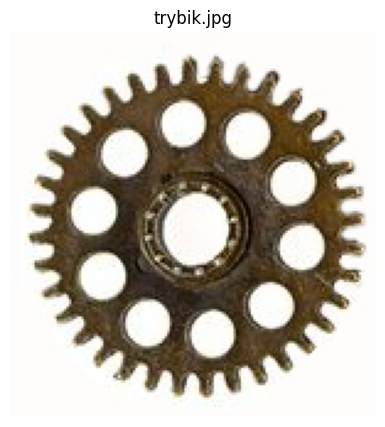

In [ ]:
trybik = images_color['trybik.jpg']
trybik_gray = images_gray['trybik.jpg']
trybik_rgb = cv2.cvtColor(trybik, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))
plt.subplot(1, 1, 1)
plt.title('trybik.jpg')
plt.imshow(trybik_rgb)
plt.axis('off')

In [ ]:
# Binaryzacja
_, bin_img = cv2.threshold(trybik_gray, 128, 255, cv2.THRESH_BINARY)

# Negacja – aby kontur był biały na czarnym tle
bin_img = cv2.bitwise_not(bin_img)

# Znajdowanie konturów
contours, hierarchy = cv2.findContours(bin_img, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

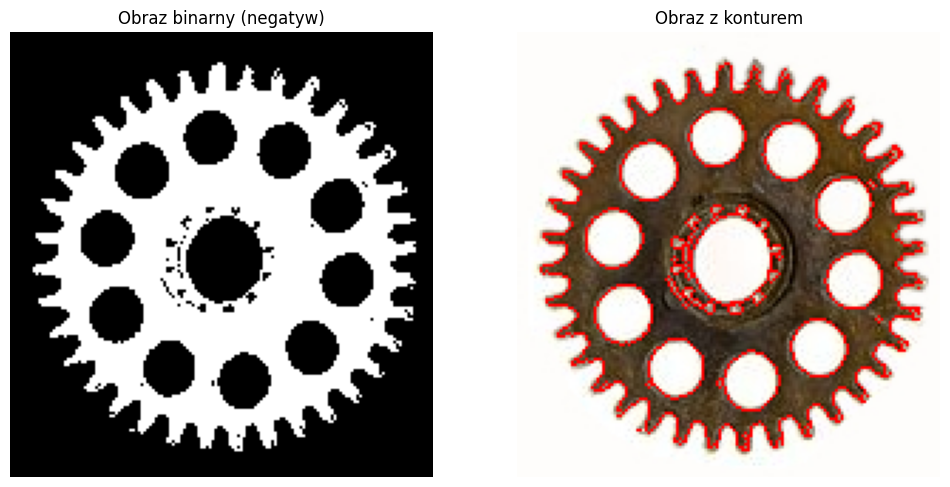

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Obraz binarny (negatyw)')
plt.imshow(bin_img, cmap='gray')
plt.axis('off')

img_contours = trybik_rgb.copy()
plt.subplot(1, 2, 2)
plt.title('Obraz z konturem')
plt.imshow(cv2.drawContours(img_contours, contours, -1, [255,0,0], 1))
plt.axis('off')
plt.show()

In [ ]:
# wyznaczanie gradientów
sobelx = cv2.Sobel(trybik_gray,cv2.CV_64F,1,0,ksize=5)
sobely = cv2.Sobel(trybik_gray,cv2.CV_64F,0,1,ksize=5)

amplitude_matrix = np.sqrt(sobelx**2 + sobely**2)

gradient_orientation_matrix = np.arctan2(sobely, sobelx)
gradient_orientation_matrix = np.deg2rad(gradient_orientation_matrix)
gradient_orientation_matrix = np.mod(gradient_orientation_matrix, 360)

In [ ]:
# środek ciężkości
M = cv2.moments(bin_img, 1)
center_x = int(M['m10'] / M['m00'])
center_y = int(M['m01'] / M['m00'])

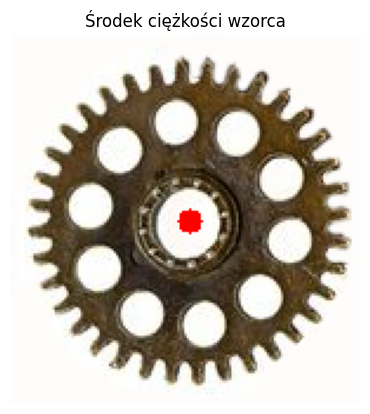

In [ ]:
img_marked = trybik_rgb.copy()
cv2.circle(img_marked, (center_x, center_y), radius=5, color=(255, 0, 0), thickness=-1)

plt.imshow(img_marked)
plt.title("Środek ciężkości wzorca")
plt.axis('off')
plt.show()

In [ ]:
# r-table
r_table = [[] for _ in range(360)]

for contour in contours:
  for point in contour:
      x, y = point[0]

      # Obliczanie orientacji gradientu (z macierzy orientacji)
      angle = gradient_orientation_matrix[y, x]
      angle_int = int(angle) % 360

      # Wektor od punktu konturu do środka ciężkości
      dx = center_x - x
      dy = center_y - y

      # Współrzędne biegunowe: r, theta (kąt względem osi OX)
      r = np.sqrt(dx**2 + dy**2)
      theta = np.degrees(np.arctan2(dy, dx)) % 360

      r_table[angle_int].append((r, theta))

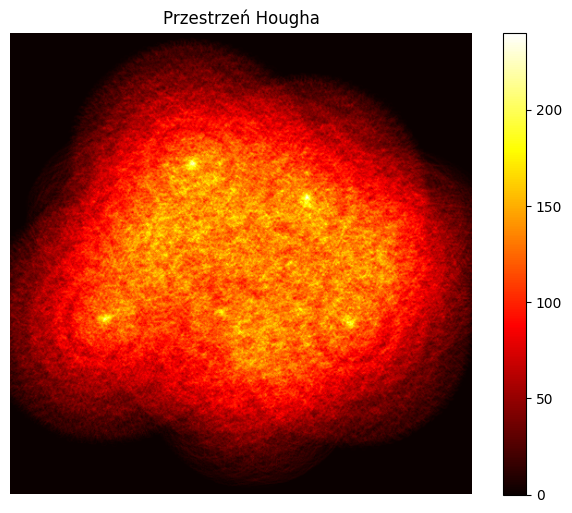

In [ ]:
scene = images_color['trybiki2.jpg']
scene_gray = images_gray['trybiki2.jpg']

sobelx = cv2.Sobel(scene_gray, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(scene_gray, cv2.CV_64F, 0, 1, ksize=5)
amplitude2 = np.sqrt(sobelx**2 + sobely**2)
normalized_amplitude = amplitude2 / np.amax(amplitude2)

orientation2 = np.arctan2(sobely, sobelx)
orientation2 = np.deg2rad(orientation2)
orientation2 = np.mod(orientation2, 360)

accumulator = np.zeros_like(scene_gray, dtype=np.uint64)
height, width = scene_gray.shape

# Próg amplitudy gradientu
threshold = 0.5

# główna pętla po pikselach
for y in range(1, height - 1):
    for x in range(1, width - 1):
        if normalized_amplitude[y, x] > threshold:
            gradient_angle = int(orientation2[y, x]) % 360
            entries = r_table[gradient_angle]

            for (r, phi) in entries:
                # oblicz przewidywaną pozycję środka obiektu
                # x1 = int(round(-r * np.cos(np.radians(phi)) + x))
                # y1 = int(round(-r * np.sin(np.radians(phi)) + y))
                x1 = int(round(-r * np.cos(phi) + x))
                y1 = int(round(-r * np.sin(phi) + y))

                # sprawdź czy wewnątrz obrazu
                if 0 <= x1 < width and 0 <= y1 < height:
                    accumulator[y1, x1] += 1


# Wizualizacja przestrzeni Hougha
plt.figure(figsize=(8, 6))
plt.imshow(accumulator, cmap='hot')
plt.title("Przestrzeń Hougha")
plt.colorbar()
plt.axis('off')
plt.show()

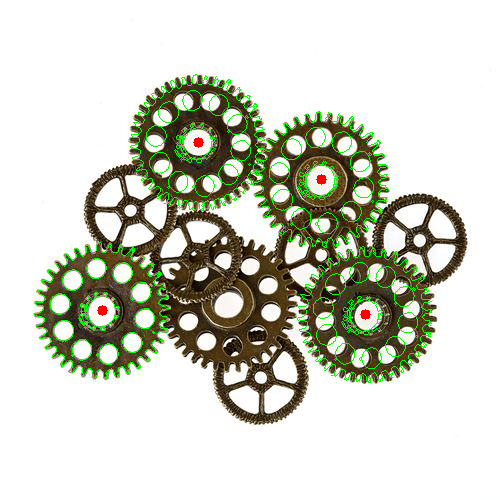

In [ ]:
from scipy.ndimage import maximum_filter
local_max = (accumulator == maximum_filter(accumulator, size=180))
peaks = np.where((accumulator >= 0.6*np.max(accumulator)) & local_max)

scene = scene.copy()
for m_y,m_x in zip(*peaks):
    dx = m_x - center_x
    dy = m_y - center_y
    shifted_contours = []
    for cnt in contours:
        cnt_shifted = cnt + np.array([[[dx, dy]]])
        shifted_contours.append(cnt_shifted)

    cv2.drawContours(scene, shifted_contours, -1, (0, 255, 0), 1)
    cv2.circle(scene, (m_x, m_y), 5, (0, 0, 255), -1)
cv2_imshow(scene)